<a href="https://colab.research.google.com/github/EltonBraga2025/EltonBraga2025/blob/main/Projeto_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📁 analise-pagamentos-administrativos/
├── projeto_analise_pagamentos.ipynb
├── relatorio_pagamentos.xlsx
├── README.md


# 📊 Análise de Pagamentos Administrativos

Este projeto simula uma análise de dados administrativos de pagamentos a fornecedores, com o objetivo de identificar atrasos, valores pagos e a eficiência dos processos internos. É ideal para profissionais em transição para a área de Dados que possuem bagagem em rotinas administrativas.

## 🎯 Objetivo

- Monitorar prazos de pagamento
- Avaliar a média de dias para pagamento por fornecedor
- Visualizar o status geral dos pagamentos
- Aplicar ferramentas de análise de dados em um cenário realista

## 🛠️ Tecnologias Utilizadas

- Python
- pandas
- matplotlib
- seaborn
- Jupyter Notebook

## 📁 Arquivos do Projeto

- `projeto_analise_pagamentos.ipynb`: Notebook com todo o passo a passo da análise
- `relatorio_pagamentos.xlsx`: Planilha com os dados simulados exportados do projeto

## 📊 Visualizações Geradas

- Total pago por fornecedor
- Tempo médio de pagamento por fornecedor
- Distribuição do status de pagamentos

## 💡 Aprendizados

- Manipulação de datas e dados administrativos com pandas
- Visualização de dados com matplotlib e seaborn
- Exportação para Excel
- Construção de indicadores úteis para análise de processos

## 📍 Autor

Elton Braga  
[LinkedIn](https://www.linkedin.com/in/elton-braga-485937bb)

---

**Projeto desenvolvido como parte do processo de transição de carreira para a área de Análise de Dados.**


📁 Estrutura dos dados (simulados):

Teremos um DataFrame com os seguintes campos:

Fornecedor – Nome do fornecedor

Data_Emissao – Data da emissão da nota fiscal

Data_Pagamento – Data em que o pagamento foi realizado

Valor – Valor da nota

Status – Pago / Em aberto

📋 Visão geral dos dados:
   Fornecedor Data_Emissao Data_Pagamento  Valor     Status  Dias_Para_Pagar
0  Alpha Ltda   2025-01-05     2025-01-15   1500       Pago             10.0
1     Beta SA   2025-01-10     2025-01-20   2300       Pago             10.0
2    Gamma ME   2025-01-12            NaT   1200  Em aberto              NaN
3  Alpha Ltda   2025-02-01     2025-02-10   1800       Pago              9.0
4  Delta Corp   2025-02-10     2025-03-01   2500       Pago             19.0
5     Beta SA   2025-02-15     2025-02-25   2200       Pago             10.0
6    Gamma ME   2025-02-18            NaT   1300  Em aberto              NaN


<ipython-input-1-58c00e1c34d2>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valor_total.values, y=valor_total.index, palette='viridis')


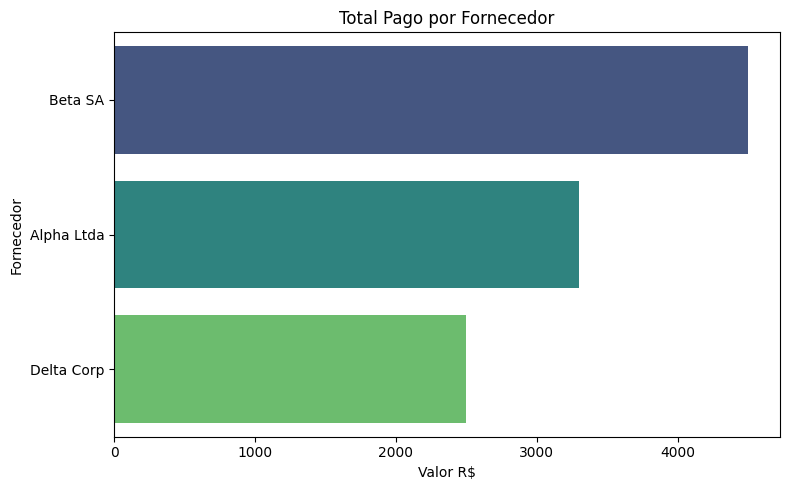

<ipython-input-1-58c00e1c34d2>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dias_media.values, y=dias_media.index, palette='Blues_d')


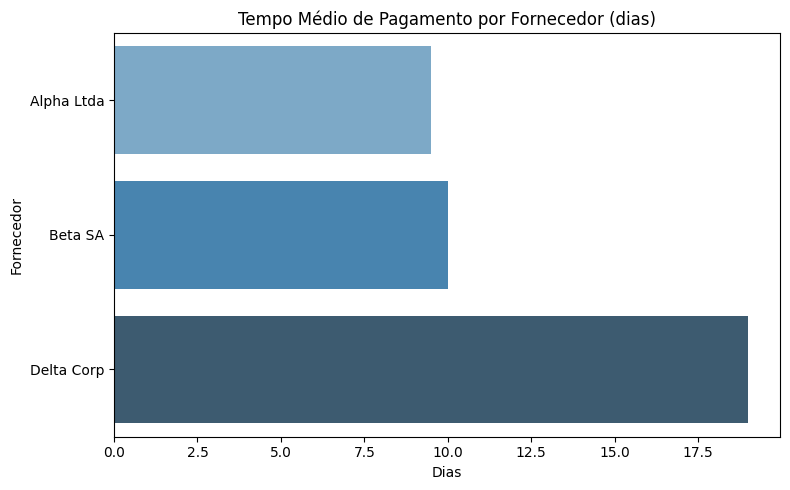

<ipython-input-1-58c00e1c34d2>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


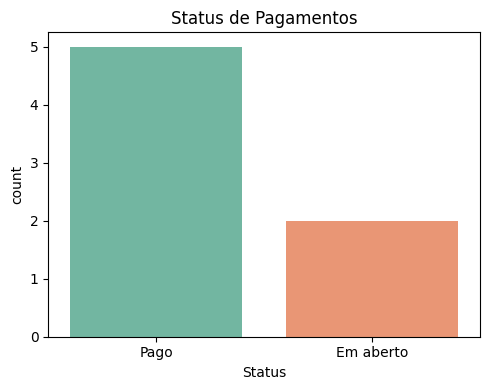

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Simulação de dados
dados = {
    'Fornecedor': ['Alpha Ltda', 'Beta SA', 'Gamma ME', 'Alpha Ltda', 'Delta Corp', 'Beta SA', 'Gamma ME'],
    'Data_Emissao': ['2025-01-05', '2025-01-10', '2025-01-12', '2025-02-01', '2025-02-10', '2025-02-15', '2025-02-18'],
    'Data_Pagamento': ['2025-01-15', '2025-01-20', None, '2025-02-10', '2025-03-01', '2025-02-25', None],
    'Valor': [1500, 2300, 1200, 1800, 2500, 2200, 1300],
    'Status': ['Pago', 'Pago', 'Em aberto', 'Pago', 'Pago', 'Pago', 'Em aberto']
}

# Criar DataFrame
df = pd.DataFrame(dados)

# Converter datas
df['Data_Emissao'] = pd.to_datetime(df['Data_Emissao'])
df['Data_Pagamento'] = pd.to_datetime(df['Data_Pagamento'])

# Calcular dias até pagamento
df['Dias_Para_Pagar'] = (df['Data_Pagamento'] - df['Data_Emissao']).dt.days

# Exibir DataFrame
print("📋 Visão geral dos dados:")
print(df)

# Análise de valores pagos por fornecedor
pagos = df[df['Status'] == 'Pago']
valor_total = pagos.groupby('Fornecedor')['Valor'].sum().sort_values(ascending=False)

# Visualização 1: Total pago por fornecedor
plt.figure(figsize=(8, 5))
sns.barplot(x=valor_total.values, y=valor_total.index, palette='viridis')
plt.title('Total Pago por Fornecedor')
plt.xlabel('Valor R$')
plt.ylabel('Fornecedor')
plt.tight_layout()
plt.show()

# Visualização 2: Dias médios para pagamento por fornecedor
dias_media = pagos.groupby('Fornecedor')['Dias_Para_Pagar'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=dias_media.values, y=dias_media.index, palette='Blues_d')
plt.title('Tempo Médio de Pagamento por Fornecedor (dias)')
plt.xlabel('Dias')
plt.ylabel('Fornecedor')
plt.tight_layout()
plt.show()

# Visualização 3: Status de pagamentos
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Status de Pagamentos')
plt.tight_layout()
plt.show()
